# Кросс-валидация, оценка моделей и подбор гиперпараметров

В этом ноутбуке подробно разбираются:

1. Что такое кросс-валидация и, самое главное, **зачем она нужна**.
2. Основные виды кросс-валидации в scikit-learn: `KFold`, `StratifiedKFold`,
   `LeaveOneOut`, `LeavePOut`, `ShuffleSplit`, `StratifiedShuffleSplit`,
   `GroupKFold`, `TimeSeriesSplit`, `RepeatedKFold` и функция `cross_validate`
   — с параметрами, плюсами/минусами и примерами кода.
3. Подбор гиперпараметров: наивный перебор, `GridSearchCV`, `RandomizedSearchCV`,
   Successive Halving и вложенная (nested) кросс-валидация.
4. Практическая функция, определяющая, **репрезентативна ли выборка**
   (adversarial validation).
5. **Coarse-to-fine search** — стратегия «сначала грубо, потом точно» —
   и собственный класс `CoarseToFineSearchCV`, реализующий интерфейс
   `BaseSearchCV` из scikit-learn.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import modules.plots as mplts

from sklearn.datasets import load_iris
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.svm import SVC
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    ShuffleSplit, StratifiedShuffleSplit,
    GroupKFold,
    RepeatedStratifiedKFold,
    TimeSeriesSplit,
    cross_validate,
    train_test_split,
    cross_val_score
) 
from sklearn.datasets import make_blobs

%matplotlib inline

## 1. Что такое кросс-валидация и зачем она нужна

До сих пор для оценки качества модели мы поступали просто: один раз
разбивали данные на обучающую и тестовую выборки функцией
`train_test_split`, обучали модель на train, считали метрику на test —
и получали **одно число**.

Проблема в том, что это число сильно зависит от того, *как именно*
данные оказались разбиты. Если тестовая выборка случайно получилась
«лёгкой» — правильность будет завышена; если «трудной» — занижена.
Особенно остро это проявляется на небольших датасетах, где даже
несколько «неудачных» примеров в тестовой выборке заметно сдвигают
метрику.

Ниже — простой эксперимент: обучим одну и ту же модель на одних и тех
же данных 200 раз, каждый раз меняя только `random_state` в
`train_test_split`, и посмотрим на разброс полученной правильности.

Правильность (одно разбиение), min/mean/max: 0.889 / 0.960 / 1.000
Стандартное отклонение: 0.025


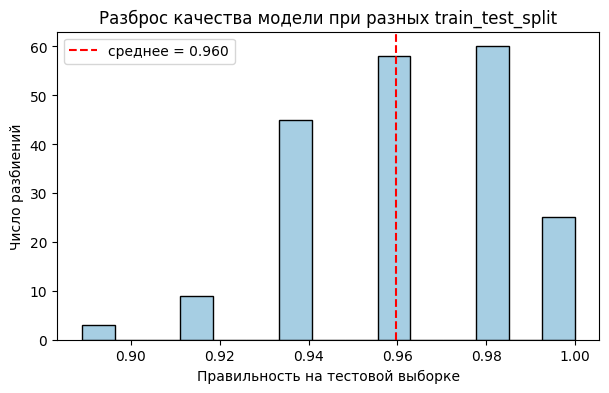

In [2]:
iris = load_iris()
single_split_scores = []
for seed in range(200):
    X_train, X_test, y_train, y_test = train_test_split(
        iris.data, iris.target, test_size=0.3, random_state=seed)
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    single_split_scores.append(model.score(X_test, y_test))

single_split_scores = np.array(single_split_scores)
print("Правильность (одно разбиение), min/mean/max: {:.3f} / {:.3f} / {:.3f}".format(
    single_split_scores.min(), single_split_scores.mean(), single_split_scores.max()))
print("Стандартное отклонение: {:.3f}".format(single_split_scores.std()))

plt.figure(figsize=(7, 4))
plt.hist(single_split_scores, bins=15, color="#a6cee3", edgecolor="black")
plt.axvline(single_split_scores.mean(), color="red", linestyle="--",
            label="среднее = {:.3f}".format(single_split_scores.mean()))
plt.xlabel("Правильность на тестовой выборке")
plt.ylabel("Число разбиений")
plt.title("Разброс качества модели при разных train_test_split")
plt.legend()
plt.show()

Видно, что в зависимости от `random_state` правильность заметно
«гуляет». Один-единственный `train_test_split` — это, по сути, одно
случайное наблюдение из целого распределения возможных оценок
качества, и полагаться на него рискованно, особенно когда:

* данных немного, и один «неудачный» тестовый набор сильно искажает
  оценку;
* мы сравниваем несколько моделей или подбираем гиперпараметры и
  выбираем «лучшую» — легко выбрать модель, которая просто удачно
  легла на конкретный тестовый набор (data leakage);
* нужно понимать не только среднее качество, но и его **разброс**
  (насколько стабильно ведёт себя модель).

**Кросс-валидация (перекрёстная проверка)** решает эти проблемы: данные
разбиваются на несколько частей (блоков, folds), и по очереди каждая
часть побывает тестовой, а модель обучается заново на оставшихся
данных. В итоге вместо одного числа мы получаем *несколько* оценок
качества, по которым можно посчитать среднее и разброс (std).

Самый распространённый вариант — **k-блочная кросс-проверка
(k-fold cross-validation)**: данные делятся на *k* примерно равных
блоков (обычно k=5 или k=10), и модель обучается и тестируется *k* раз,
каждый раз с новым блоком в роли тестового.

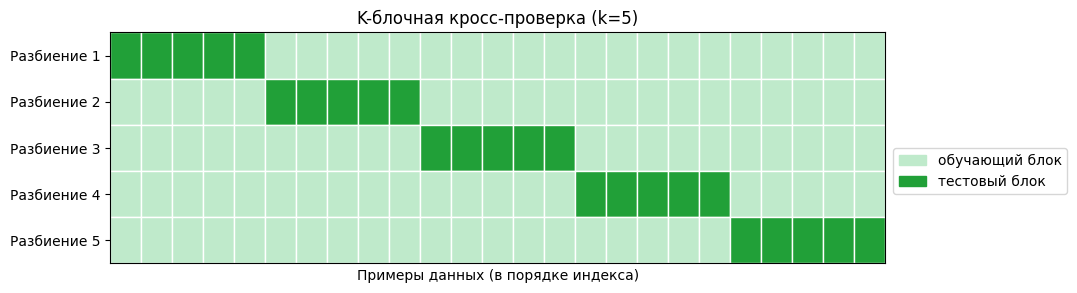

In [3]:
mplts.plot_cross_validation(n_splits=5)
plt.show()

In [4]:
logreg = LogisticRegression(max_iter=1000)
scores = cross_val_score(logreg, iris.data, iris.target, cv=5)
print("Оценки правильности по 5 блокам:", np.round(scores, 3))
print("Средняя правильность: {:.3f}".format(scores.mean()))
print("Стандартное отклонение: {:.3f}".format(scores.std()))

Оценки правильности по 5 блокам: [0.967 1.    0.933 0.967 1.   ]
Средняя правильность: 0.973
Стандартное отклонение: 0.025


### Зачем именно нужна кросс-валидация — коротко по пунктам

1. **Более надёжная и устойчивая оценка качества.** Усреднение по
   нескольким разным разбиениям снижает дисперсию оценки — на неё
   меньше влияет "везение" или "невезение" одного конкретного
   разбиения (см. эксперимент выше: `std` по k-fold обычно заметно
   меньше, чем разброс отдельных `train_test_split`).
2. **Эффективное использование данных.** При k-fold CV каждый пример
   побывает и в обучающей, и в тестовой выборке (ровно один раз — в
   тестовой). Это особенно важно на небольших датасетах, где жалко
   "терять" данные на постоянный тестовый набор.
3. **Оценка разброса (стабильности) качества модели**, а не только
   единственного числа: значение `scores.std()` показывает, насколько
   сильно качество модели зависит от конкретного разбиения данных —
   это тоже важная характеристика модели.
4. **Честный подбор гиперпараметров.** Если для выбора гиперпараметров
   многократно смотреть на один и тот же тестовый набор, происходит
   неявная "утечка" информации о нём в процесс выбора модели, и
   итоговая оценка качества становится слишком оптимистичной.
   Кросс-валидация на *обучающей* части данных позволяет подбирать
   гиперпараметры, ни разу не заглядывая в тестовую выборку (о этом
   подробнее — в разделе 3).
5. **Возможность выявить проблемы с данными**, например, слишком
   сильную зависимость модели от конкретных примеров, или ситуацию,
   когда сортировка/группировка данных приводит к тому, что в одном
   из блоков отсутствует целый класс (см. далее про `StratifiedKFold`
   и `GroupKFold`).

Важно понимать: кросс-валидация — это **не способ построить одну
"лучшую" модель**. Как метод она возвращает несколько временных
моделей, обученных внутри процедуры, но они, как правило,
выбрасываются, а на выходе остаётся не сама модель, а более надёжная
**оценка её качества** (и, по итогам, — финальная модель обучается
заново уже на всех данных).

## 2. Виды кросс-валидации в scikit-learn

Все методы разбиения (splitters) в scikit-learn имеют единый интерфейс:
метод `.split(X, y, groups)`, который возвращает индексы `train`/`test`
для каждой итерации. Это позволяет использовать их взаимозаменяемо —
в том числе передавая параметр `cv=` в `cross_val_score`,
`cross_validate`, `GridSearchCV` и т.д.

### Как получить сами индексы: итерирование по `.split()`

Все "разбивалки" из примера выше (и все, что рассматриваются далее)
не хранят готовые выборки — они по запросу генерируют пары индексов
`(train_idx, test_idx)`. Функции `cross_val_score`/`cross_validate`/
`GridSearchCV` делают это автоматически внутри себя, но точно так же
по любому сплиттеру можно **проитерироваться вручную** — это полезно,
когда нужна нестандартная логика на каждом блоке (свои метрики,
сохранение предсказаний, дообучение и т.п.), а не просто число.

Ниже — общий паттерн, работающий одинаково для `KFold`,
`StratifiedKFold`, `ShuffleSplit`, `GroupKFold` и всех остальных
сплиттеров ниже: на каждой итерации `.split(X, y, groups)` отдаёт
следующую пару массивов индексов.

In [5]:
demo_kfold = KFold(n_splits=5, shuffle=True, random_state=0)

manual_scores = []
for fold_i, (train_idx, test_idx) in enumerate(demo_kfold.split(iris.data, iris.target)):
    X_tr, X_te = iris.data[train_idx], iris.data[test_idx]
    y_tr, y_te = iris.target[train_idx], iris.target[test_idx]

    model = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
    fold_score = model.score(X_te, y_te)
    manual_scores.append(fold_score)

    print(f"Блок {fold_i}: train={len(train_idx)} объектов, "
          f"test={len(test_idx)} объектов, accuracy={fold_score:.3f}")

print("\nСреднее по ручному циклу: {:.3f}".format(np.mean(manual_scores)))
print("Для сравнения cross_val_score с тем же KFold: {:.3f}".format(
    cross_val_score(LogisticRegression(max_iter=1000), iris.data, iris.target,
                     cv=demo_kfold).mean()))

Блок 0: train=120 объектов, test=30 объектов, accuracy=1.000
Блок 1: train=120 объектов, test=30 объектов, accuracy=0.833
Блок 2: train=120 объектов, test=30 объектов, accuracy=1.000
Блок 3: train=120 объектов, test=30 объектов, accuracy=1.000
Блок 4: train=120 объектов, test=30 объектов, accuracy=0.933

Среднее по ручному циклу: 0.953
Для сравнения cross_val_score с тем же KFold: 0.953


### 2.1 `KFold`

Базовый вариант: данные делятся на `n_splits` последовательных блоков.

**Параметры:** `n_splits` (число блоков, по умолчанию 5), `shuffle`
(перемешивать ли данные перед разбиением на блоки, по умолчанию
`False`), `random_state` (фиксирует перемешивание, если `shuffle=True`).

**Плюсы:**
* прост и понятен, "эталонная" схема кросс-валидации;
* каждый пример ровно один раз оказывается в тестовом блоке;
* подходит и для классификации, и для регрессии.

**Минусы (ограничения):**
* если `shuffle=False` (по умолчанию!) и данные упорядочены — например,
  отсортированы по классам, как часто бывает в учебных датасетах —
  блоки могут оказаться сильно несбалансированными по классам, вплоть
  до полного отсутствия класса в блоке;
* не учитывает структуру данных (группы, временной порядок и т.д.).

Ниже — наглядная демонстрация проблемы: `iris` отсортирован по классам,
поэтому `KFold(shuffle=False)` на нём "ломается".

In [6]:
print("Классы в iris.target идут по порядку:", np.unique(iris.target, return_counts=True))

logreg = LogisticRegression(max_iter=1000)

kfold_no_shuffle = KFold(n_splits=3)  # shuffle=False по умолчанию!
scores_bad = cross_val_score(logreg, iris.data, iris.target, cv=kfold_no_shuffle)
print("KFold(shuffle=False), 3 блока:", scores_bad)

kfold_shuffle = KFold(n_splits=3, shuffle=True, random_state=0)
scores_good = cross_val_score(logreg, iris.data, iris.target, cv=kfold_shuffle)
print("KFold(shuffle=True), 3 блока: ", np.round(scores_good, 3))

Классы в iris.target идут по порядку: (array([0, 1, 2]), array([50, 50, 50]))
KFold(shuffle=False), 3 блока: [0. 0. 0.]
KFold(shuffle=True), 3 блока:  [0.98 0.96 0.96]


Видно, что без перемешивания правильность на каждом блоке равна
**0**: каждый блок целиком состоит из одного класса, которого модель
никогда не видела на обучении. Перемешивание (`shuffle=True`) решает
проблему — но всё равно не гарантирует одинаковое соотношение классов
в каждом блоке. Для этого нужен `StratifiedKFold`.

### 2.2 `StratifiedKFold`

Стратифицированный вариант k-блочной проверки: блоки формируются так,
чтобы в каждом сохранялась (примерно) исходная пропорция классов.

**Параметры:** `n_splits`, `shuffle`, `random_state` — те же, что и у
`KFold`.

**Плюсы:**
* сохраняет пропорции классов в каждом блоке — даёт более надёжную и
  менее шумную оценку для классификации, особенно при небольшом числе
  примеров или несбалансированных классах;
* в scikit-learn используется **по умолчанию**, когда `cv` задаётся
  просто числом (`cv=5`) и оценивается классификатор.

**Минусы (ограничения):**
* неприменим "как есть" к регрессии (нет дискретных классов для
  стратификации — хотя существуют обходные пути через биннинг целевой
  переменной);
* если какого-то класса меньше, чем `n_splits`, стратификация
  невозможна (будет ошибка);
* как и `KFold`, не учитывает группы/временной порядок.

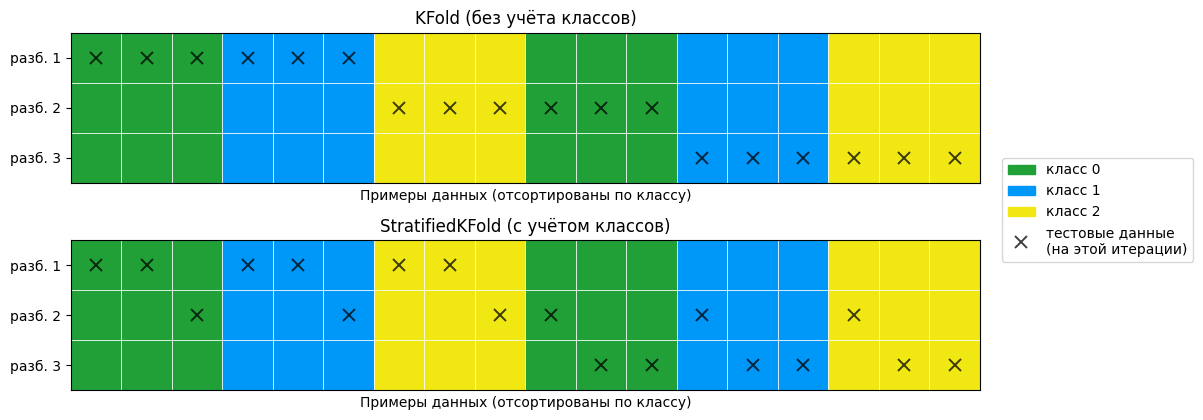

In [7]:
mplts.plot_stratified_cross_validation()
plt.show()

In [8]:
skfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
scores_strat = cross_val_score(logreg, iris.data, iris.target, cv=skfold)
print("StratifiedKFold, 3 блока:", np.round(scores_strat, 3))
print("Среднее: {:.3f}, std: {:.3f}".format(scores_strat.mean(), scores_strat.std()))

StratifiedKFold, 3 блока: [0.96 0.98 0.94]
Среднее: 0.960, std: 0.016


### 2.3 `LeaveOneOut` (LOO) и `LeavePOut`

`LeaveOneOut` — предельный случай k-блочной проверки, когда
`n_splits == n_samples`: на каждой итерации тестовым является ровно
**один** пример, а все остальные — обучающими.

**Параметры:** у `LeaveOneOut` параметров нет — число разбиений всегда
равно числу примеров. У `LeavePOut` есть параметр `p` — число объектов,
оставляемых в тестовую выборку на каждой итерации (перебираются все
возможные сочетания из `p` объектов).

**Плюсы:**
* максимальное использование обучающих данных на каждой итерации (в
  обучении участвуют `n-1` примеров) — полезно для очень маленьких
  датасетов;
* никакой случайности — результат детерминирован (в отличие от
  ShuffleSplit).

**Минусы (ограничения):**
* очень требователен к вычислениям: нужно обучить модель `n` раз (для
  `LeavePOut` — `C(n, p)` раз, что быстро становится астрономическим
  числом);
* оценка качества на каждой итерации по одному примеру — очень
  "шумная" метрика (accuracy на 1 объекте — это либо 0, либо 1);
  в сумме такая CV может давать *высокую дисперсию* итоговой оценки,
  несмотря на низкое смещение (bias);
* плохо подходит для больших датасетов.

In [9]:
# для скорости берём укороченную версию iris (по 10 примеров каждого класса)
_, X_small, _, y_small = train_test_split(
    iris.data, iris.target, test_size=30, stratify=iris.target, random_state=0)

loo = LeaveOneOut()
scores_loo = cross_val_score(logreg, X_small, y_small, cv=loo)
print("Число разбиений LeaveOneOut:", len(scores_loo))
print("Средняя правильность: {:.3f}".format(scores_loo.mean()))
print("Пример значений (первые 10):", scores_loo[:10])

Число разбиений LeaveOneOut: 30
Средняя правильность: 1.000
Пример значений (первые 10): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 2.4 `ShuffleSplit` и `StratifiedShuffleSplit`

В отличие от `KFold`, где данные один раз делятся на `n_splits`
непересекающихся блоков, `ShuffleSplit` на **каждой** итерации заново
случайным образом выбирает `train_size` объектов в обучающую выборку и
`test_size` — в тестовую (независимо от предыдущих итераций). Часть
объектов может не попасть ни в одну из выборок на конкретной
итерации, а часть — попасть в тестовую выборку несколько раз за разные
итерации.

**Параметры:** `n_splits` (число итераций), `train_size`, `test_size`
(доли от 0 до 1 либо абсолютные числа объектов), `random_state`.
`StratifiedShuffleSplit` — то же самое, но с сохранением пропорций
классов на каждой итерации (аналог `StratifiedKFold` для `ShuffleSplit`).

**Плюсы:**
* число итераций (`n_splits`) отвязано от размера train/test — можно
  сделать хоть 100 итераций с небольшой тестовой выборкой, что
  невозможно в `KFold` (там число блоков жёстко связано с их размером);
* удобно "подсэмплировать" большие датасеты (задать `train_size`
  меньше 100% данных) — быстрее гонять эксперименты;
* гибкий независимый контроль над размерами train и test.

**Минусы (ограничения):**
* нет гарантии, что каждый объект попадёт в тестовую выборку хотя бы
  один раз (в отличие от `KFold`, где это гарантировано) — часть
  данных может вообще ни разу не использоваться для проверки;
* некоторые объекты тестируются чаще других — оценка может быть слегка
  смещена в их сторону;
* (для базового `ShuffleSplit`) не учитывает баланс классов — для
  классификации обычно предпочтительнее `StratifiedShuffleSplit`.

На схеме ниже по оси **X** — индекс объекта в исходном датасете (это
просто порядковый номер объекта в массиве данных, а не время и не
класс). Каждая строка — одна независимая случайная итерация:

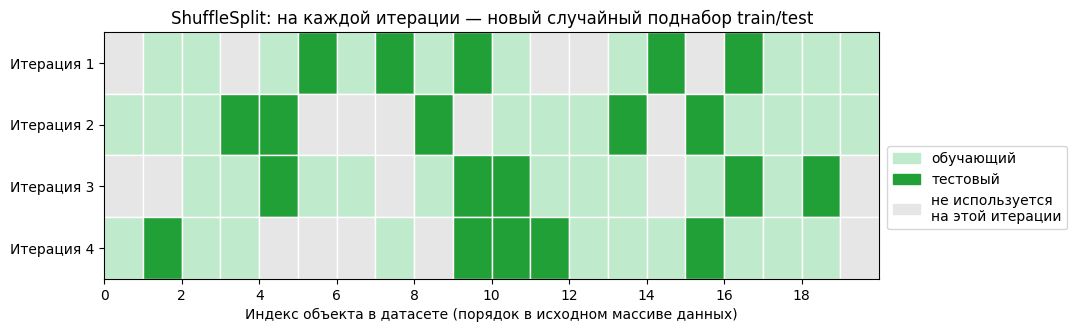

In [10]:
mplts.plot_shuffle_split()
plt.show()

In [11]:
shuffle_split = ShuffleSplit(n_splits=10, train_size=0.7, test_size=0.3, random_state=0)
scores_ss = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)
print("ShuffleSplit, 10 итераций:", np.round(scores_ss, 3))

strat_shuffle_split = StratifiedShuffleSplit(n_splits=10, train_size=0.7,
                                              test_size=0.3, random_state=0)
scores_sss = cross_val_score(logreg, iris.data, iris.target, cv=strat_shuffle_split)
print("StratifiedShuffleSplit, 10 итераций:", np.round(scores_sss, 3))

ShuffleSplit, 10 итераций: [0.978 0.933 0.956 0.911 0.978 0.933 1.    1.    1.    0.978]
StratifiedShuffleSplit, 10 итераций: [1.    0.978 0.978 0.978 0.956 0.956 0.978 0.978 0.978 0.956]


### 2.5 `GroupKFold` (и `GroupShuffleSplit`, `LeaveOneGroupOut`)

Используется, когда объекты не независимы друг от друга, а образуют
группы — например, несколько снимков одного пациента, несколько
записей одного пользователя, несколько строк одной компании и т.д.
Если объекты одной группы случайно окажутся и в train, и в test,
модель может просто "запомнить" группу — и оценка качества будет
завышена (это частный случай утечки данных, *data leakage*).
`GroupKFold` гарантирует, что вся группа целиком попадает **либо** в
обучающую, **либо** в тестовую выборку.

**Параметры:** `n_splits`. В `.split(X, y, groups)` дополнительно
передаётся массив `groups` — метка группы для каждого объекта.

**Плюсы:**
* предотвращает утечку данных между train и test через связанные
  объекты — даёт честную оценку обобщающей способности на *новые*
  группы (пациентов, пользователей и т.п.);
* легко встраивается в любой pipeline, где уже используется `cv=`.

**Минусы (ограничения):**
* требует явно заданных меток групп, которые не всегда доступны;
* блоки могут получиться существенно разного размера, если размеры
  групп сильно различаются (алгоритм старается их сбалансировать, но
  не всегда идеально);
* не гарантирует сохранение пропорций классов (нет "стратифицированной"
  версии GroupKFold в стабильном API одновременно с группировкой и
  стратификацией — для этого есть `StratifiedGroupKFold`).

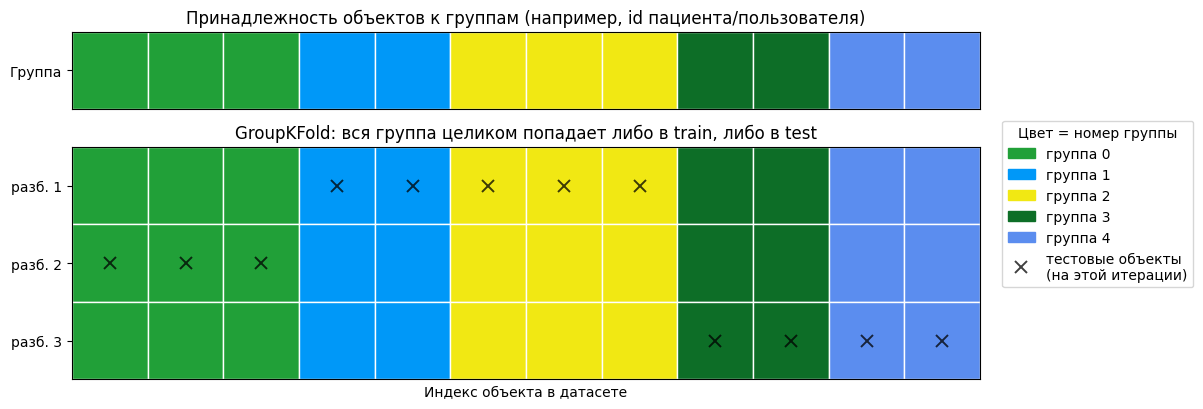

In [12]:
mplts.plot_group_kfold()
plt.show()

In [13]:
# синтетические данные: 12 объектов, объединённых в 5 групп
X_g, y_g = make_blobs(n_samples=12, random_state=0)
groups = np.array([0, 0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4])

gkf = GroupKFold(n_splits=3)
for i, (train_idx, test_idx) in enumerate(gkf.split(X_g, y_g, groups=groups)):
    print(f"Разбиение {i}: группы в train = {sorted(set(groups[train_idx]))}, "
          f"группы в test = {sorted(set(groups[test_idx]))}")

scores_gkf = cross_val_score(logreg, X_g, y_g, cv=gkf, groups=groups)
print("Оценки:", np.round(scores_gkf, 3))

Разбиение 0: группы в train = [np.int64(0), np.int64(3), np.int64(4)], группы в test = [np.int64(1), np.int64(2)]
Разбиение 1: группы в train = [np.int64(1), np.int64(2), np.int64(3), np.int64(4)], группы в test = [np.int64(0)]
Разбиение 2: группы в train = [np.int64(0), np.int64(1), np.int64(2)], группы в test = [np.int64(3), np.int64(4)]
Оценки: [0.8   0.667 0.75 ]


### 2.6 `TimeSeriesSplit`

Специальный вариант для **временных рядов**, где нарушать порядок
времени нельзя: тестовые данные всегда идут *после* обучающих по
времени (иначе модель будет "подглядывать в будущее" — look-ahead
bias).

**Параметры:** `n_splits`, `max_train_size` (ограничение на размер
обучающей выборки — именно им переключаются между двумя подходами
ниже), `test_size`, `gap` (сколько наблюдений пропустить между train и
test — чтобы избежать утечки через скользящие признаки, посчитанные с
использованием окна вокруг границы train/test).

**Плюсы:**
* единственный "честный" способ кросс-валидации для данных с временной
  зависимостью — сохраняет причинно-следственный порядок;
* хорошо соответствует реальному сценарию использования модели
  (прогноз будущего по прошлому).

**Минусы (ограничения) — общие для обоих подходов:**
* нельзя произвольно перемешивать данные (`shuffle` недоступен) —
  меньше гибкости, чем у остальных сплиттеров;
* на первых итерациях обучающих данных может быть мало;
* не подходит, если данные не имеют временной природы (заведомо
  избыточное ограничение).

У `TimeSeriesSplit` есть два принципиально разных режима работы —
они задаются параметром `max_train_size`.

#### Вариант A — расширяющееся (кумулятивное) окно (`max_train_size=None`, по умолчанию)

На каждой следующей итерации в обучающую выборку добавляется очередной
"кусок" новых данных, а старые данные никогда не выбрасываются —
train растёт от итерации к итерации.

**Плюсы:**
* использует **всю** доступную историю — ничего не выбрасывается;
* даёт более стабильную (менее шумную) оценку параметров модели на
  поздних итерациях, так как обучающая выборка большая;
* хорошо подходит, когда закономерность в данных стабильна во времени
  (данные стационарны).

**Минусы:**
* обучающая выборка на разных итерациях имеет разный размер — оценки
  качества на разных блоках менее сопоставимы между собой;
* время обучения модели растёт от итерации к итерации;
* если распределение данных со временем меняется (data drift), старые,
  уже неактуальные данные "разбавляют" полезный сигнал из недавних
  наблюдений и могут ухудшать качество.

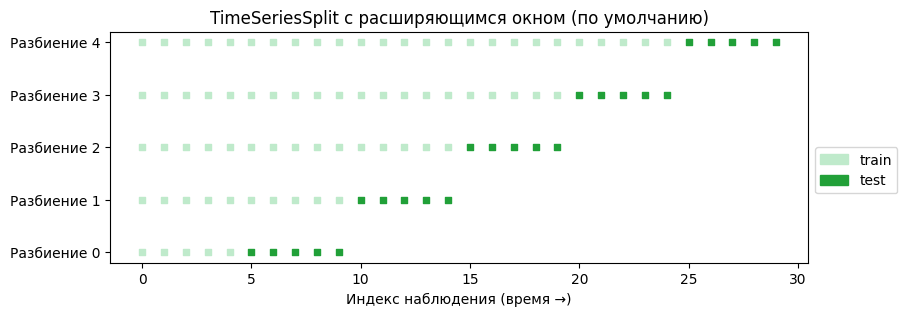

In [14]:
mplts.plot_time_series_split(n_points=30, n_splits=5, max_train_size=None)
plt.show()

#### Вариант B — скользящее окно фиксированной длины (`max_train_size=N`)

Обучающая выборка на каждой итерации имеет **одинаковый** размер `N`:
как только появляются новые ("свежие") данные, из начала окна
выбрасывается столько же самых старых наблюдений — окно "едет" вперёд
по времени, не увеличиваясь.

**Плюсы:**
* лучше подходит для **нестационарных** данных, где старые
  закономерности со временем становятся неактуальными (data drift) —
  модель обучается только на относительно недавней истории;
* время обучения (и объём данных) одинаковы на каждой итерации —
  оценки качества между блоками более сопоставимы;
* более реалистично имитирует продакшен-сценарий, где модель
  периодически переобучается на "скользящем" окне последних N
  наблюдений (например, последних 90 дней), а не на всей истории с
  начала времён.

**Минусы:**
* сознательно выбрасывается потенциально полезная старая информация —
  если закономерность на самом деле стабильна, качество может быть
  хуже, чем при расширяющемся окне;
* появляется дополнительный гиперпараметр — размер окна `N`
  (`max_train_size`), который тоже нужно подбирать: слишком маленький
  N — модель недообучена и её оценки шумные; слишком большой —
  фактически вырождается в расширяющееся окно;
* на ранних итерациях (пока истории меньше N) обучающая выборка всё
  равно будет меньше номинального размера окна.

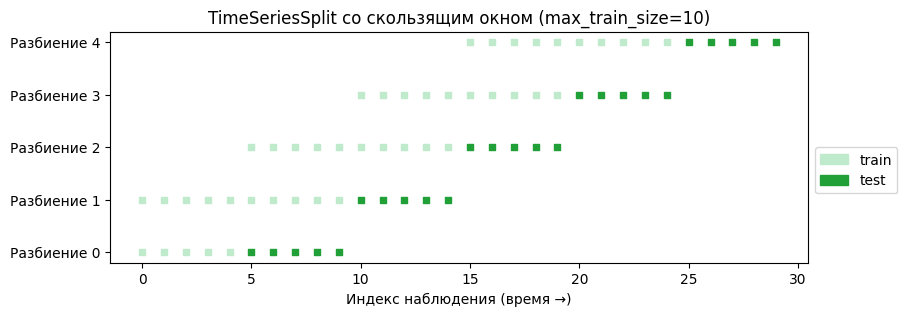

In [15]:
mplts.plot_time_series_split(n_points=30, n_splits=5, max_train_size=10)
plt.show()

In [16]:
# Практическая иллюстрация на конкретной модели: сравним качество
# двух режимов TimeSeriesSplit на одних и тех же синтетических данных
# временного ряда с трендом и небольшим дрейфом распределения.
rng = np.random.RandomState(0)
n_points = 200
t = np.arange(n_points)
# сигнал постепенно меняет характер во времени (имитация data drift)
y_ts = 0.02 * t + 0.5 * np.sin(t / (8 + t / 40)) + rng.normal(scale=0.3, size=n_points)
X_ts = t.reshape(-1, 1)

for max_train_size, label in [(None, "расширяющееся окно"), (40, "скользящее окно (N=40)")]:
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=max_train_size)
    fold_errors = []
    for train_idx, test_idx in tscv.split(X_ts):
        model = Ridge(alpha=1.0).fit(X_ts[train_idx], y_ts[train_idx])
        pred = model.predict(X_ts[test_idx])
        fold_errors.append(np.mean((pred - y_ts[test_idx]) ** 2))
    print(f"{label:28s}: MSE по блокам = {np.round(fold_errors, 3)}, "
          f"среднее = {np.mean(fold_errors):.3f}")

расширяющееся окно          : MSE по блокам = [0.33  1.493 0.318 0.273 0.295], среднее = 0.542
скользящее окно (N=40)      : MSE по блокам = [0.33  0.309 0.957 1.116 0.326], среднее = 0.608


### 2.7 `RepeatedKFold` / `RepeatedStratifiedKFold`

Повторяет обычный `KFold`/`StratifiedKFold` `n_repeats` раз с разными
случайными перемешиваниями данных и объединяет все полученные оценки.

**Параметры:** `n_splits`, `n_repeats`, `random_state`.

**Плюсы:**
* дополнительно снижает дисперсию итоговой оценки качества (усреднение
  идёт уже не по k, а по `k * n_repeats` значениям);
* особенно полезен на небольших датасетах, где даже единственный
  k-fold даёт заметный разброс между запусками с разными `random_state`.

**Минусы (ограничения):**
* вычислительные затраты растут прямо пропорционально `n_repeats` —
  модель обучается `n_splits * n_repeats` раз;
* отдельные повторы не являются полностью независимыми (используются
  одни и те же данные), поэтому выигрыш в точности оценки — не такой,
  как от сбора нового независимого датасета такого же объёма.

In [17]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=0)
scores_rskf = cross_val_score(logreg, iris.data, iris.target, cv=rskf)
print("RepeatedStratifiedKFold: {} оценок (5 блоков x 4 повтора)".format(len(scores_rskf)))
print("Среднее: {:.3f}, std: {:.3f}".format(scores_rskf.mean(), scores_rskf.std()))

RepeatedStratifiedKFold: 20 оценок (5 блоков x 4 повтора)
Среднее: 0.965, std: 0.036


### 2.8 Функция `cross_validate`

В отличие от `cross_val_score`, которая возвращает только массив
значений одной метрики, `cross_validate` — более гибкая функция,
позволяющая одновременно считать **несколько метрик**, а также
возвращать время обучения/предсказания, сами обученные модели и
оценки на обучающей выборке (для диагностики переобучения).

**Основные параметры:** `estimator`, `X`, `y`, `groups`, `scoring`
(строка, список строк или словарь `{имя: scorer}`), `cv`, `n_jobs`,
`return_train_score` (по умолчанию `False`), `return_estimator`
(вернуть обученные на каждом блоке модели), `error_score`.

**Плюсы:**
* несколько метрик за один проход по данным (не нужно гонять CV
  отдельно под каждую метрику);
* `return_train_score=True` позволяет сравнить качество на train и на
  test и увидеть переобучение;
* `return_estimator=True` даёт доступ к самим обученным на блоках
  моделям (например, для анализа важности признаков на каждом блоке).

**Минусы (ограничения):**
* возвращает словарь, а не просто массив — требуется чуть больше кода
  для распаковки результата;
* по-прежнему не решает задачу подбора гиперпараметров сама по себе —
  для этого нужны `GridSearchCV`/`RandomizedSearchCV` (раздел 3).

In [18]:
digits = load_digits()
# бинарная задача: цифра 9 против остальных
res = cross_validate(SVC(gamma="scale"), digits.data, digits.target == 9,
                      scoring=["accuracy", "roc_auc", "recall_macro"],
                      return_train_score=True, cv=5)
display(pd.DataFrame(res))

,fit_time,score_time,test_accuracy,train_accuracy,test_roc_auc,train_roc_auc,test_recall_macro,train_recall_macro
0,0.034472,0.048070,0.975000,0.994433,0.997171,0.998679,0.887346,0.972222
1,0.021395,0.056924,0.991667,0.995825,0.998543,0.999141,0.958333,0.982252
2,0.024194,0.060272,1.000000,0.995132,1.000000,0.998975,1.000000,0.978780
3,0.029259,0.054131,0.994429,0.995828,0.999828,0.998825,0.972222,0.982252
4,0.019308,0.036491,0.980501,0.996523,0.984004,0.999914,0.902778,0.985725


### Сводная таблица по видам кросс-валидации

| Метод | Когда использовать | Основной плюс | Основной минус |
|---|---|---|---|
| `KFold` | базовый случай, регрессия | просто, каждый пример тестируется 1 раз | без `shuffle` чувствителен к порядку данных |
| `StratifiedKFold` | классификация (используется по умолчанию) | сохраняет пропорции классов | не для регрессии "из коробки" |
| `LeaveOneOut` | очень маленькие датасеты | максимум данных на обучение | очень дорого, шумная метрика |
| `LeavePOut` | очень маленькие датасеты, нужна полная комбинаторика | наиболее полная проверка всех сочетаний | комбинаторный взрыв при росте n, p |
| `ShuffleSplit` | нужен контроль над train/test size, subsampling | гибкость числа итераций и размеров | не все объекты обязательно тестируются |
| `StratifiedShuffleSplit` | то же + классификация | + сохраняет пропорции классов | то же |
| `GroupKFold` | связанные объекты (пациенты, пользователи) | не допускает утечки между train/test | нужны метки групп |
| `TimeSeriesSplit` (расширяющееся окно) | временные ряды, стационарные данные | использует всю историю, стабильная оценка | train растёт, дороже по времени |
| `TimeSeriesSplit` (скользящее окно, `max_train_size`) | временные ряды с дрейфом распределения | одинаковый размер train на каждом блоке, лучше ловит нестационарность | теряются старые данные, размер окна — доп. гиперпараметр |
| `RepeatedKFold` | нужна ещё более стабильная оценка | меньше дисперсии итоговой оценки | дороже по вычислениям |
| `cross_validate` | нужно несколько метрик / доступ к моделям | гибкость вывода | не про подбор гиперпараметров |
